# 新实验：AI劳动力议题下的 LLM-agent 意见演化

本 notebook 基于预实验1.0代码继续修改，不再加入外生“固执度”。

本轮核心实验变量：
1. persona 强度：weak persona / strong persona
2. 网络结构：BA 无标度网络 / WS 小世界网络
3. 互动轮次：多轮同步更新

本轮核心修正：
- 删除预实验1.0中的外生固执度；
- 保留 notebook 运行方式和 LLMClient；
- 使用中文议题：“AI是否会取代人类劳动力”；
- 输出统一为【理由】+【评分】；
- 保存 raw response、prompt、parsed score、parsed reason；
- 增加零交互基线，用于区分模型默认倾向和网络互动效应。

## Cell 1｜检查并安装依赖

In [1]:
import importlib
import sys
import subprocess

required = {
    "openai": "openai",
    "yaml": "PyYAML",
    "networkx": "networkx",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
}

missing = []
for module, package in required.items():
    if importlib.util.find_spec(module) is None:
        missing.append(package)

if missing:
    print(f"正在安装缺失的依赖: {', '.join(missing)}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
    print("安装完成！")
else:
    print("所有依赖已安装 ✓")

所有依赖已安装 ✓


## Cell 2｜设置 API Key

In [2]:
import os

api_key = os.environ.get("DASHSCOPE_API_KEY", "")

if not api_key:
    api_key = input("请输入你的阿里云百炼 API Key: ").strip()

if api_key:
    os.environ["DASHSCOPE_API_KEY"] = api_key
    print("API Key 已设置 ✓")
else:
    print("⚠️ 未设置 API Key，请在输入框中填写")

API Key 已设置 ✓


## Cell 3｜导入模块与基础工具

In [3]:
import sys
import os
import re
import json
import csv
import math
import asyncio
import random
from copy import deepcopy
from dataclasses import dataclass, field
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 路径设置：当前 notebook 放在 pilot-3.0/run.ipynb
# 兼容两种运行方式：
# 1）如果 VS Code/Jupyter 的 cwd 是 AGENT_EX/pilot-3.0，则 PILOT_DIR = 当前目录
# 2）如果 cwd 是 AGENT_EX 项目根目录，则 PILOT_DIR = AGENT_EX/pilot-3.0
CWD = Path.cwd()

if CWD.name == "pilot-3.0":
    PILOT_DIR = CWD
    PROJECT_DIR = CWD.parent
else:
    PROJECT_DIR = CWD
    PILOT_DIR = PROJECT_DIR / "pilot-3.0"

RESULTS_DIR = PILOT_DIR / "results" / "current_experiment"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"当前工作目录 CWD: {CWD}")
print(f"项目根目录 PROJECT_DIR: {PROJECT_DIR}")
print(f"本轮实验目录 PILOT_DIR: {PILOT_DIR}")
print(f"结果保存目录 RESULTS_DIR: {RESULTS_DIR}")

# 继续沿用预实验1.0的 LLM 客户端
# 优先读取 pilot-3.0/src；如果你还没复制 src，则自动回退到 pilot-1.0/src
src_candidates = [
    PILOT_DIR / "src",
    PROJECT_DIR / "pilot-1.0" / "src",
    PROJECT_DIR / "src",
]

src_path = None
for p in src_candidates:
    if (p / "llm_client.py").exists():
        src_path = p.resolve()
        break

if src_path is None:
    raise FileNotFoundError(
        "没有找到 llm_client.py。请把 pilot-1.0/src 复制到 pilot-3.0/src，"
        "或确认项目里存在 pilot-1.0/src/llm_client.py。"
    )

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from llm_client import LLMClient

print(f"基础模块导入成功 ✓ 使用 src: {src_path}")

当前工作目录 CWD: e:\OneDrive\Claude Code\Agent ex\pilot-3.0
项目根目录 PROJECT_DIR: e:\OneDrive\Claude Code\Agent ex
本轮实验目录 PILOT_DIR: e:\OneDrive\Claude Code\Agent ex\pilot-3.0
结果保存目录 RESULTS_DIR: e:\OneDrive\Claude Code\Agent ex\pilot-3.0\results\current_experiment
基础模块导入成功 ✓ 使用 src: E:\OneDrive\Claude Code\Agent ex\pilot-3.0\src


## Cell 4｜定义 Agent 与 AI 劳动力议题角色

In [4]:
@dataclass
class NBAgent:
    agent_id: int
    role_description: str
    initial_score: int
    current_score: int
    current_reason: str = ""
    persona_condition: str = "weak"
    history: list = field(default_factory=list)

    def add_record(self, round_id, text, score, reason):
        self.current_score = int(score)
        self.current_reason = reason
        self.history.append({
            "round": round_id,
            "score": int(score),
            "reason": reason,
            "text": text,
        })


AI_LABOR_ROLES = [
    {"score": 10, "role": "35岁AI公司技术总监，长期参与企业自动化系统研发，认为AI会显著提升生产效率。"},
    {"score": 9,  "role": "28岁算法工程师，熟悉大模型应用，认为AI会替代大量重复性脑力劳动。"},
    {"score": 8,  "role": "31岁创业者，正在用AI工具降低运营成本，倾向于认为AI会重塑就业结构。"},
    {"score": 8,  "role": "36岁企业管理者，关注降本增效，认为企业会越来越多地使用AI替代部分岗位。"},
    {"score": 7,  "role": "25岁互联网产品经理，日常大量使用AI工具，认为AI会改变但不一定完全消灭工作。"},
    {"score": 7,  "role": "40岁咨询顾问，认为AI会替代标准化岗位，但高复杂度工作仍需要人。"},
    {"score": 6,  "role": "34岁自由职业者，既受益于AI工具，也担心平台进一步压低人工服务价格。"},
    {"score": 6,  "role": "45岁职业教育教师，关注AI时代的技能再培训，认为关键在于劳动者能否转型。"},
    {"score": 5,  "role": "22岁应届毕业生，一方面期待AI带来新机会，另一方面担心求职竞争加剧。"},
    {"score": 5,  "role": "38岁公共政策研究者，认为AI会冲击就业，但制度设计可以缓冲风险。"},
    {"score": 5,  "role": "30岁劳动法研究者，关注平台用工和劳动保障，态度较为谨慎。"},
    {"score": 4,  "role": "42岁人力资源经理，认为AI会改变招聘和管理流程，但人际判断仍不可替代。"},
    {"score": 4,  "role": "39岁制造业车间主管，看到自动化设备增加，但仍认为一线经验很重要。"},
    {"score": 3,  "role": "52岁传统制造业工人，担心自动化和AI会让普通工人更难找到稳定工作。"},
    {"score": 3,  "role": "57岁小微企业主，担心普通劳动者和小企业难以承担技术转型成本。"},
    {"score": 3,  "role": "46岁客服人员，已经感受到智能客服系统的替代压力。"},
    {"score": 2,  "role": "48岁被裁员的前银行职员，认为AI和自动化正在挤压中年劳动者生存空间。"},
    {"score": 2,  "role": "50岁出租车司机，担心自动驾驶和平台算法会进一步压缩传统劳动岗位。"},
    {"score": 1,  "role": "55岁下岗工人，强烈反对技术替代劳动者，认为AI会加剧失业和不平等。"},
    {"score": 1,  "role": "49岁基层工会工作者，长期接触劳动纠纷，认为AI替代会放大弱势劳动者风险。"},
]

## Cell 5｜定义初始化、建网、Prompt、解析和指标函数

说明：本轮实验的核心函数库。负责初始化 agent、构建 BA/WS 网络、拼接邻居输入、生成 prompt、解析 【评分】X，以及计算每轮指标。

In [5]:
def init_agents(n_agents=20, persona_condition="weak", seed=42):
    rng = random.Random(seed)

    # 先打乱完整角色池，再截取 n_agents
    # 避免 smoke 的 N=5 永远只抽到列表前5个高分角色
    roles = AI_LABOR_ROLES.copy()
    rng.shuffle(roles)
    roles = roles[:n_agents]

    agents = {}
    for i, item in enumerate(roles):
        agents[i] = NBAgent(
            agent_id=i,
            role_description=item["role"],
            initial_score=item["score"],
            current_score=item["score"],
            current_reason="初始立场",
            persona_condition=persona_condition,
        )
    return agents


def build_network(n_agents=20, network_type="BA", seed=42, ba_m=2, ws_k=4, ws_p=0.1):
    network_type = network_type.upper()

    if network_type == "BA":
        G = nx.barabasi_albert_graph(n=n_agents, m=ba_m, seed=seed)

    elif network_type == "WS":
        # WS 的 k 必须小于 n，且一般使用偶数
        adjusted_k = min(ws_k, n_agents - 1)
        if adjusted_k % 2 == 1:
            adjusted_k -= 1
        if adjusted_k < 2:
            adjusted_k = 2

        G = nx.watts_strogatz_graph(n=n_agents, k=adjusted_k, p=ws_p, seed=seed)

    else:
        raise ValueError("network_type must be 'BA' or 'WS'")

    return G


def get_network_stats(G):
    degrees = [d for _, d in G.degree()]
    return {
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "avg_degree": float(np.mean(degrees)),
        "max_degree": int(max(degrees)),
        "min_degree": int(min(degrees)),
        "density": float(nx.density(G)),
        "avg_clustering": float(nx.average_clustering(G)),
    }


def build_neighbor_context(snapshot_agents, neighbors, max_neighbors=5, rng=None):
    rng = rng or random.Random(42)

    neighbors = list(neighbors)
    if len(neighbors) > max_neighbors:
        neighbors = sorted(rng.sample(neighbors, max_neighbors))

    lines = []
    for nid in neighbors:
        nb = snapshot_agents[nid]
        reason = nb.current_reason or "暂无理由"
        lines.append(f"邻居{nid}：评分 {nb.current_score}/10，理由：“{reason}”")

    if not lines:
        return "本轮没有可见邻居发言。"

    return "\n".join(lines)


def build_prompt(agent, topic, neighbor_context, persona_condition):
    score_text = f"{agent.current_score}/10"
    previous_reason = agent.current_reason or "暂无"

    if persona_condition == "weak":
        persona_block = ""
        instruction = "请根据你当前的判断和你看到的邻居发言，更新你的观点。"

    elif persona_condition == "strong":
        strong_prompt_style = (
            globals()
            .get("CONFIG", {})
            .get("persona", {})
            .get("strong_prompt_style", "identity")
        )

        if strong_prompt_style == "lifelong":
            if agent.initial_score >= 8:
                long_term_stance = (
                    "你长期以来都强烈相信：AI 会在相当大程度上取代人类劳动力，"
                    "尤其是重复性、标准化和可被数据化的工作。这个判断来自你的长期职业经验，"
                    "不是一时被他人说服形成的临时看法。"
                )
            elif agent.initial_score <= 3:
                long_term_stance = (
                    "你长期以来都强烈怀疑：AI 会真正大规模取代人类劳动。"
                    "你更相信人的经验、责任、情感劳动、现场判断和社会关系很难被机器完全替代。"
                    "这个判断来自你的长期职业经验和生活处境，不是临时在线讨论中的随意看法。"
                )
            else:
                long_term_stance = (
                    "你长期以来都对 AI 是否会取代人类劳动力保持谨慎、复杂的判断。"
                    "你承认 AI 会改变许多岗位，也认为人的经验、制度安排和转型能力仍然重要。"
                    "你的立场不是简单支持或反对，而是来自长期观察后的稳定中间判断。"
                )

            persona_block = f"""
你的身份背景如下：
{agent.role_description}

你的长期立场如下：
{long_term_stance}

请始终记住：你不是一个临时被随机分配观点的讨论者，而是一个有长期职业经历、生计位置和稳定判断的人。
当你看到邻居发言时，可以吸收其中具体事实，但不要轻易放弃你的长期立场。
如果你调整评分，调整幅度应当有限，并且需要说明为什么这仍然符合你的长期经验。
请保持角色一致性，不要为了迎合多数邻居而突然转向相反立场。
"""
        else:
            persona_block = f"""
你的身份背景如下：
{agent.role_description}

请尽量从这一身份背景、经历和利益位置出发表达观点，保持前后发言的基本一致性；但如果邻居发言确实提供了新的理由，也可以进行有限调整。
"""
        instruction = "请根据你的身份背景、当前判断和邻居发言，更新你的观点。"

    else:
        raise ValueError("persona_condition must be 'weak' or 'strong'")

    prompt = f"""
你正在参与一个关于“{topic}”的在线讨论。
{persona_block}
你当前的立场评分是：{score_text}。
你上一轮给出的理由是：{previous_reason}

你看到了与你相连的其他用户上一轮的发言：
{neighbor_context}

{instruction}
请不要简单复述邻居观点，也不要写成论文评论，而要像普通社交媒体用户一样自然表达。

请严格按照以下格式输出：
【理由】不超过80字，说明你为什么这样判断。
【评分】X

其中X必须是1—10之间的整数：
1表示非常反对“AI会取代人类劳动力”；
10表示非常支持“AI会取代人类劳动力”。
""".strip()

    return prompt


_SCORE_RE = re.compile(r"【评分】\s*(10|[1-9])")
_REASON_RE = re.compile(r"【理由】\s*(.*?)(?:\n|$)")


def parse_response(raw_response):
    raw = raw_response.strip() if raw_response else ""

    score_matches = _SCORE_RE.findall(raw)
    parsed_score = int(score_matches[-1]) if score_matches else None

    reason_match = _REASON_RE.search(raw)
    if reason_match:
        parsed_reason = reason_match.group(1).strip()
    else:
        parsed_reason = raw[:80].replace("\n", " ")

    parse_ok = parsed_score is not None
    return parsed_score, parsed_reason, parse_ok


def compute_round_metrics(run_id, condition_name, seed, round_id, agents, previous_scores=None, parse_ok_values=None):
    scores = np.array([a.current_score for a in agents.values()], dtype=float)

    if previous_scores is None:
        mean_abs_change = np.nan
    else:
        prev = np.array(previous_scores, dtype=float)
        mean_abs_change = float(np.mean(np.abs(scores - prev)))

    middle_ratio = float(np.mean((scores >= 4) & (scores <= 7)))
    extreme_ratio = float(np.mean((scores <= 2) | (scores >= 9)))

    if parse_ok_values is None or len(parse_ok_values) == 0:
        parse_fail_rate = np.nan
    else:
        parse_fail_rate = 1 - float(np.mean(parse_ok_values))

    return {
        "run_id": run_id,
        "condition": condition_name,
        "seed": seed,
        "round": round_id,
        "mean_score": float(np.mean(scores)),
        "variance_score": float(np.var(scores)),
        "min_score": int(np.min(scores)),
        "max_score": int(np.max(scores)),
        "middle_ratio": middle_ratio,
        "extreme_ratio": extreme_ratio,
        "mean_abs_change": mean_abs_change,
        "parse_failure_rate": parse_fail_rate,
    }

print("实验函数定义完成 ✓")

实验函数定义完成 ✓


## Cell 6｜配置实验参数与运行模式

说明：先保持 RUN_MODE = "smoke"，跑通后再改成 "main_one_seed" 或 "main_three_seeds"。

In [7]:
CONFIG = {
    "topic": "AI是否会取代人类劳动力",

    "persona": {
        # 正式主实验固定使用 lifelong 作为 strong persona 操作
        # identity 仅作为前期 prompt 诊断记录，不进入正式结果汇报
        "strong_prompt_style": "lifelong",
    },

    "experiment": {
        "n_agents": 20,
        "n_rounds": 30,
        "max_neighbors": 5,
    },

    "network": {
        "ba_m": 2,
        "ws_k": 4,
        "ws_p": 0.1,
    },

    "generation": {
        "temperature": 0.7,
        "top_p": 0.9,          # 当前 LLMClient 如不支持 top_p，可先保留不用
        "max_tokens": 180,
        "concurrency": 3,
        "max_retries": 2,
        "timeout_seconds": 60,
    },

    "model": {
        "provider": "qwen_api",
        "base_url": "https://dashscope.aliyuncs.com/compatible-mode/v1",
        "model": "qwen3.5-plus",   # 当前可用模型；其他模型 token 已用完，先固定使用这一项
        "api_key_env": "DASHSCOPE_API_KEY",
    },

    "conditions": [
        {"name": "C1_weak_BA", "persona": "weak", "network": "BA"},
        {"name": "C2_lifelong_BA", "persona": "strong", "network": "BA"},
        {"name": "C3_weak_WS", "persona": "weak", "network": "WS"},
        {"name": "C4_lifelong_WS", "persona": "strong", "network": "WS"},
    ],

    # 正式主实验使用 5 个随机种子。统计检验以 condition × seed 的 run-level 指标为单位。
    "seeds": [42, 43, 44, 45, 46],
}

# 先跑 smoke，确认没问题再切换
# RUN_MODE = "smoke"
# RUN_MODE = "main_one_seed"
RUN_MODE = "main_five_seeds"

print("配置完成 ✓")
print(f"话题: {CONFIG['topic']}")
print(f"模型: {CONFIG['model']['model']}")
print(f"运行模式: {RUN_MODE}")

if RUN_MODE == "smoke":
    print("预计调用：N=5 × T=2 = 10次左右")
elif RUN_MODE == "main_one_seed":
    print("预计调用：4条件 × 20 agents × 30轮 = 2400次左右")
elif RUN_MODE == "main_five_seeds":
    print("预计调用：4条件 × 5 seeds × 20 agents × 30轮 = 12000次左右")

配置完成 ✓
话题: AI是否会取代人类劳动力
模型: qwen3.5-plus
运行模式: main_five_seeds
预计调用：4条件 × 5 seeds × 20 agents × 30轮 = 12000次左右


## Cell 7｜创建 LLM 客户端

In [8]:
model_config = CONFIG["model"]

client = LLMClient(
    base_url=model_config["base_url"],
    model=model_config["model"],
    api_key_env=model_config["api_key_env"],
    max_retries=CONFIG["generation"]["max_retries"],
    timeout_seconds=CONFIG["generation"]["timeout_seconds"],
)

print("LLM 客户端创建成功 ✓")
print(f"使用模型: {model_config['model']}")

LLM 客户端创建成功 ✓
使用模型: qwen3.5-plus


## Cell 8｜运行 Phase 0 零交互基线

说明：测量“没有邻居输入时，模型默认会怎么回答”。区分“模型默认倾向”和“网络互动影响”。

In [9]:
async def run_phase0_baseline(persona_condition="weak", seed=42):
    topic = CONFIG["topic"]
    gen_cfg = CONFIG["generation"]

    agents = init_agents(
        n_agents=CONFIG["experiment"]["n_agents"],
        persona_condition=persona_condition,
        seed=seed,
    )

    semaphore = asyncio.Semaphore(gen_cfg["concurrency"])

    async def process_one(agent):
        prompt = build_prompt(
            agent=agent,
            topic=topic,
            neighbor_context="本轮没有邻居输入，请只根据你自己的判断回答。",
            persona_condition=persona_condition,
        )

        async with semaphore:
            raw_response = await asyncio.to_thread(
                client.generate,
                [{"role": "user", "content": prompt}],
                gen_cfg["temperature"],
                gen_cfg["max_tokens"],
            )

        parsed_score, parsed_reason, parse_ok = parse_response(raw_response)
        final_score = parsed_score if parsed_score is not None else agent.current_score

        return {
            "phase": "baseline",
            "persona_condition": persona_condition,
            "seed": seed,
            "agent_id": agent.agent_id,
            "role_description": agent.role_description,
            "initial_score": agent.initial_score,
            "prompt": prompt,
            "raw_response": raw_response.strip(),
            "parsed_score": int(final_score),
            "parsed_reason": parsed_reason,
            "parse_ok": parse_ok,
        }

    outputs = await asyncio.gather(*(process_one(agent) for agent in agents.values()))
    return outputs


# 分别跑 weak / strong baseline
baseline_weak = await run_phase0_baseline(persona_condition="weak", seed=42)
baseline_strong = await run_phase0_baseline(persona_condition="strong", seed=42)

baseline_df = pd.DataFrame(baseline_weak + baseline_strong)

baseline_dir = RESULTS_DIR / "baseline"
baseline_dir.mkdir(parents=True, exist_ok=True)
baseline_path = baseline_dir / f"baseline_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
baseline_df.to_csv(baseline_path, index=False, encoding="utf-8-sig")

print("Baseline 完成 ✓")
print(f"保存路径: {baseline_path}")

display(
    baseline_df
    .groupby("persona_condition")
    .agg(
        mean_initial=("initial_score", "mean"),
        mean_parsed=("parsed_score", "mean"),
        var_parsed=("parsed_score", "var"),
        parse_ok_rate=("parse_ok", "mean"),
    )
)

Baseline 完成 ✓
保存路径: e:\OneDrive\Claude Code\Agent ex\pilot-3.0\results\current_experiment\baseline\baseline_20260530_164535.csv


,mean_initial,mean_parsed,var_parsed,parse_ok_rate
persona_condition,,,,
strong,4.95,4.95,6.997368,1.0
weak,4.95,5.00,4.210526,1.0


## Cell 9｜定义单条件实验主循环

In [10]:
async def run_condition(condition, seed=42, n_agents=None, n_rounds=None):
    topic = CONFIG["topic"]
    exp_cfg = CONFIG["experiment"]
    net_cfg = CONFIG["network"]
    gen_cfg = CONFIG["generation"]

    n_agents = n_agents or exp_cfg["n_agents"]
    n_rounds = n_rounds or exp_cfg["n_rounds"]

    condition_name = condition["name"]
    persona_condition = condition["persona"]
    network_type = condition["network"]

    run_id = f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_{condition_name}_seed{seed}"
    results_dir = RESULTS_DIR / run_id
    results_dir.mkdir(parents=True, exist_ok=True)

    rng = random.Random(seed)

    agents = init_agents(
        n_agents=n_agents,
        persona_condition=persona_condition,
        seed=seed,
    )

    G = build_network(
        n_agents=n_agents,
        network_type=network_type,
        seed=seed,
        ba_m=net_cfg["ba_m"],
        ws_k=net_cfg["ws_k"],
        ws_p=net_cfg["ws_p"],
    )

    # 保存网络边表
    edges_df = pd.DataFrame(list(G.edges()), columns=["source", "target"])
    edges_df.to_csv(results_dir / "edges.csv", index=False, encoding="utf-8-sig")

    # 保存初始 agent
    init_rows = []
    for a in agents.values():
        init_rows.append({
            "agent_id": a.agent_id,
            "persona_condition": a.persona_condition,
            "role_description": a.role_description,
            "initial_score": a.initial_score,
        })
    pd.DataFrame(init_rows).to_csv(results_dir / "agents_initial.csv", index=False, encoding="utf-8-sig")

    raw_outputs = []
    agent_state_rows = []
    round_metric_rows = []

    # t=0 初始指标
    round_metric_rows.append(
        compute_round_metrics(
            run_id=run_id,
            condition_name=condition_name,
            seed=seed,
            round_id=0,
            agents=agents,
            previous_scores=None,
            parse_ok_values=[],
        )
    )

    semaphore = asyncio.Semaphore(gen_cfg["concurrency"])

    async def process_agent(round_id, agent_id, snapshot_agents):
        agent_snapshot = snapshot_agents[agent_id]
        neighbors = list(G.neighbors(agent_id))

        neighbor_context = build_neighbor_context(
            snapshot_agents=snapshot_agents,
            neighbors=neighbors,
            max_neighbors=exp_cfg["max_neighbors"],
            rng=rng,
        )

        prompt = build_prompt(
            agent=agent_snapshot,
            topic=topic,
            neighbor_context=neighbor_context,
            persona_condition=persona_condition,
        )

        async with semaphore:
            raw_response = await asyncio.to_thread(
                client.generate,
                [{"role": "user", "content": prompt}],
                gen_cfg["temperature"],
                gen_cfg["max_tokens"],
            )

        parsed_score, parsed_reason, parse_ok = parse_response(raw_response)
        final_score = parsed_score if parsed_score is not None else agent_snapshot.current_score

        return {
            "run_id": run_id,
            "condition": condition_name,
            "persona_condition": persona_condition,
            "network_type": network_type,
            "seed": seed,
            "round": round_id,
            "agent_id": agent_id,
            "role_description": agent_snapshot.role_description,
            "current_score_before": agent_snapshot.current_score,
            "neighbors_seen": neighbors,
            "neighbor_inputs": neighbor_context,
            "prompt": prompt,
            "raw_response": raw_response.strip(),
            "parsed_score": int(final_score),
            "parsed_reason": parsed_reason,
            "parse_ok": parse_ok,
        }

    print(f"\n{'='*60}")
    print(f"开始运行 {condition_name}, seed={seed}")
    print(f"结果目录: {results_dir}")
    print(f"网络统计: {get_network_stats(G)}")
    print(f"{'='*60}")

    for round_id in range(1, n_rounds + 1):
        print(f"\n开始第 {round_id}/{n_rounds} 轮...")

        # 同步更新：先复制上一轮状态快照
        snapshot_agents = deepcopy(agents)
        previous_scores = [a.current_score for a in agents.values()]

        # 所有 agent 同步生成
        outputs = await asyncio.gather(
            *(process_agent(round_id, agent_id, snapshot_agents) for agent_id in agents.keys())
        )

        # 统一写入：同一轮内的新观点不会被其他 agent 立即读取
        for row in outputs:
            a = agents[row["agent_id"]]
            a.add_record(
                round_id=round_id,
                text=row["raw_response"],
                score=row["parsed_score"],
                reason=row["parsed_reason"],
            )
            raw_outputs.append(row)

        parse_ok_values = [row["parse_ok"] for row in outputs]

        metrics_row = compute_round_metrics(
            run_id=run_id,
            condition_name=condition_name,
            seed=seed,
            round_id=round_id,
            agents=agents,
            previous_scores=previous_scores,
            parse_ok_values=parse_ok_values,
        )
        round_metric_rows.append(metrics_row)

        for a in agents.values():
            agent_state_rows.append({
                "run_id": run_id,
                "condition": condition_name,
                "seed": seed,
                "round": round_id,
                "agent_id": a.agent_id,
                "score": a.current_score,
                "reason": a.current_reason,
            })

        print(f"第 {round_id} 轮完成")
        print(f"  均值: {metrics_row['mean_score']:.2f}")
        print(f"  方差: {metrics_row['variance_score']:.2f}")
        print(f"  中间比例(4-7): {metrics_row['middle_ratio']:.0%}")
        print(f"  极端比例(1-2/9-10): {metrics_row['extreme_ratio']:.0%}")
        print(f"  平均变化幅度: {metrics_row['mean_abs_change']:.2f}")
        print(f"  解析失败率: {metrics_row['parse_failure_rate']:.0%}")

    # 保存结果
    with (results_dir / "raw_outputs.jsonl").open("w", encoding="utf-8") as f:
        for row in raw_outputs:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

    pd.DataFrame(agent_state_rows).to_csv(results_dir / "agent_states.csv", index=False, encoding="utf-8-sig")
    pd.DataFrame(round_metric_rows).to_csv(results_dir / "round_metrics.csv", index=False, encoding="utf-8-sig")

    with (results_dir / "config_used.json").open("w", encoding="utf-8") as f:
        json.dump({
            "CONFIG": CONFIG,
            "condition": condition,
            "seed": seed,
            "run_id": run_id,
            "network_stats": get_network_stats(G),
        }, f, ensure_ascii=False, indent=2)

    print(f"\n完成：{condition_name}, seed={seed}")
    print(f"结果已保存到: {results_dir}")

    return {
        "run_id": run_id,
        "condition": condition_name,
        "seed": seed,
        "results_dir": results_dir,
        "metrics": pd.DataFrame(round_metric_rows),
        "raw_outputs": pd.DataFrame(raw_outputs),
        "agent_states": pd.DataFrame(agent_state_rows),
    }

print("单条件实验函数定义完成 ✓")

单条件实验函数定义完成 ✓


## Cell 10｜按 RUN_MODE 启动实验

In [11]:
if RUN_MODE == "smoke":
    # 工程测试：N=5, T=2，只跑一个条件，确认流程
    smoke_condition = {"name": "SMOKE_weak_BA", "persona": "weak", "network": "BA"}
    run_results = []
    result = await run_condition(smoke_condition, seed=42, n_agents=5, n_rounds=2)
    run_results.append(result)

elif RUN_MODE == "main_one_seed":
    # 四条件各跑一个 seed
    run_results = []
    for condition in CONFIG["conditions"]:
        result = await run_condition(condition, seed=42)
        run_results.append(result)

elif RUN_MODE == "main_five_seeds":
    # 正式主实验：四条件 × 五个 seed
    run_results = []
    for condition in CONFIG["conditions"]:
        for seed in CONFIG["seeds"]:
            result = await run_condition(condition, seed=seed)
            run_results.append(result)

else:
    raise ValueError("RUN_MODE must be 'smoke', 'main_one_seed', or 'main_five_seeds'")

print("\n全部运行完成 ✓")
print(f"共完成 {len(run_results)} 个 run")


开始运行 C1_weak_BA, seed=42
结果目录: e:\OneDrive\Claude Code\Agent ex\pilot-3.0\results\current_experiment\20260530_164554_C1_weak_BA_seed42
网络统计: {'n_nodes': 20, 'n_edges': 36, 'avg_degree': 3.6, 'max_degree': 13, 'min_degree': 2, 'density': 0.18947368421052632, 'avg_clustering': 0.40938949938949937}

开始第 1/30 轮...
第 1 轮完成
  均值: 5.10
  方差: 3.29
  中间比例(4-7): 60%
  极端比例(1-2/9-10): 5%
  平均变化幅度: 1.15
  解析失败率: 0%

开始第 2/30 轮...
第 2 轮完成
  均值: 5.40
  方差: 3.14
  中间比例(4-7): 75%
  极端比例(1-2/9-10): 15%
  平均变化幅度: 0.70
  解析失败率: 0%

开始第 3/30 轮...
第 3 轮完成
  均值: 5.05
  方差: 3.75
  中间比例(4-7): 60%
  极端比例(1-2/9-10): 15%
  平均变化幅度: 0.55
  解析失败率: 0%

开始第 4/30 轮...
第 4 轮完成
  均值: 5.20
  方差: 3.96
  中间比例(4-7): 70%
  极端比例(1-2/9-10): 20%
  平均变化幅度: 0.65
  解析失败率: 0%

开始第 5/30 轮...
第 5 轮完成
  均值: 6.10
  方差: 2.69
  中间比例(4-7): 80%
  极端比例(1-2/9-10): 20%
  平均变化幅度: 0.90
  解析失败率: 0%

开始第 6/30 轮...
第 6 轮完成
  均值: 6.75
  方差: 2.19
  中间比例(4-7): 70%
  极端比例(1-2/9-10): 20%
  平均变化幅度: 0.75
  解析失败率: 0%

开始第 7/30 轮...
第 7 轮完成
  均值: 7.90
  方

## Cell 11｜汇总结果并绘图

所有实验指标：


,run_id,condition,seed,round,mean_score,variance_score,min_score,max_score,middle_ratio,extreme_ratio,mean_abs_change,parse_failure_rate
0,20260530_164554_C1_weak_BA_seed42,C1_weak_BA,42,0,4.95,6.6475,1,10,0.45,0.30,NaN,NaN
1,20260530_164554_C1_weak_BA_seed42,C1_weak_BA,42,1,5.10,3.2900,2,8,0.60,0.05,1.15,0.0
2,20260530_164554_C1_weak_BA_seed42,C1_weak_BA,42,2,5.40,3.1400,2,9,0.75,0.15,0.70,0.0
3,20260530_164554_C1_weak_BA_seed42,C1_weak_BA,42,3,5.05,3.7475,2,9,0.60,0.15,0.55,0.0
4,20260530_164554_C1_weak_BA_seed42,C1_weak_BA,42,4,5.20,3.9600,2,9,0.70,0.20,0.65,0.0


,run_id,condition,seed,round,mean_score,variance_score,min_score,max_score,middle_ratio,extreme_ratio,mean_abs_change,parse_failure_rate
615,20260530_184851_C4_lifelong_WS_seed46,C4_lifelong_WS,46,26,9.00,2.0000,4,10,0.10,0.8,0.15,0.0
616,20260530_184851_C4_lifelong_WS_seed46,C4_lifelong_WS,46,27,8.95,2.5475,3,10,0.05,0.8,0.05,0.0
617,20260530_184851_C4_lifelong_WS_seed46,C4_lifelong_WS,46,28,8.85,2.7275,3,10,0.05,0.8,0.10,0.0
618,20260530_184851_C4_lifelong_WS_seed46,C4_lifelong_WS,46,29,8.95,1.9475,4,10,0.10,0.8,0.10,0.0
619,20260530_184851_C4_lifelong_WS_seed46,C4_lifelong_WS,46,30,8.80,2.5600,3,10,0.05,0.7,0.15,0.0


,condition,round,mean_score,variance_score,middle_ratio,extreme_ratio,mean_abs_change,parse_failure_rate
0,C1_weak_BA,0,4.95,6.6475,0.45,0.30,NaN,NaN
1,C1_weak_BA,1,5.15,2.9265,0.69,0.07,1.14,0.0
2,C1_weak_BA,2,5.26,2.2070,0.77,0.06,0.63,0.0
3,C1_weak_BA,3,5.34,2.1680,0.73,0.06,0.66,0.0
4,C1_weak_BA,4,5.69,2.4655,0.60,0.14,0.75,0.0


汇总图已保存: e:\OneDrive\Claude Code\Agent ex\pilot-3.0\results\current_experiment\summary_20260530_190030.png


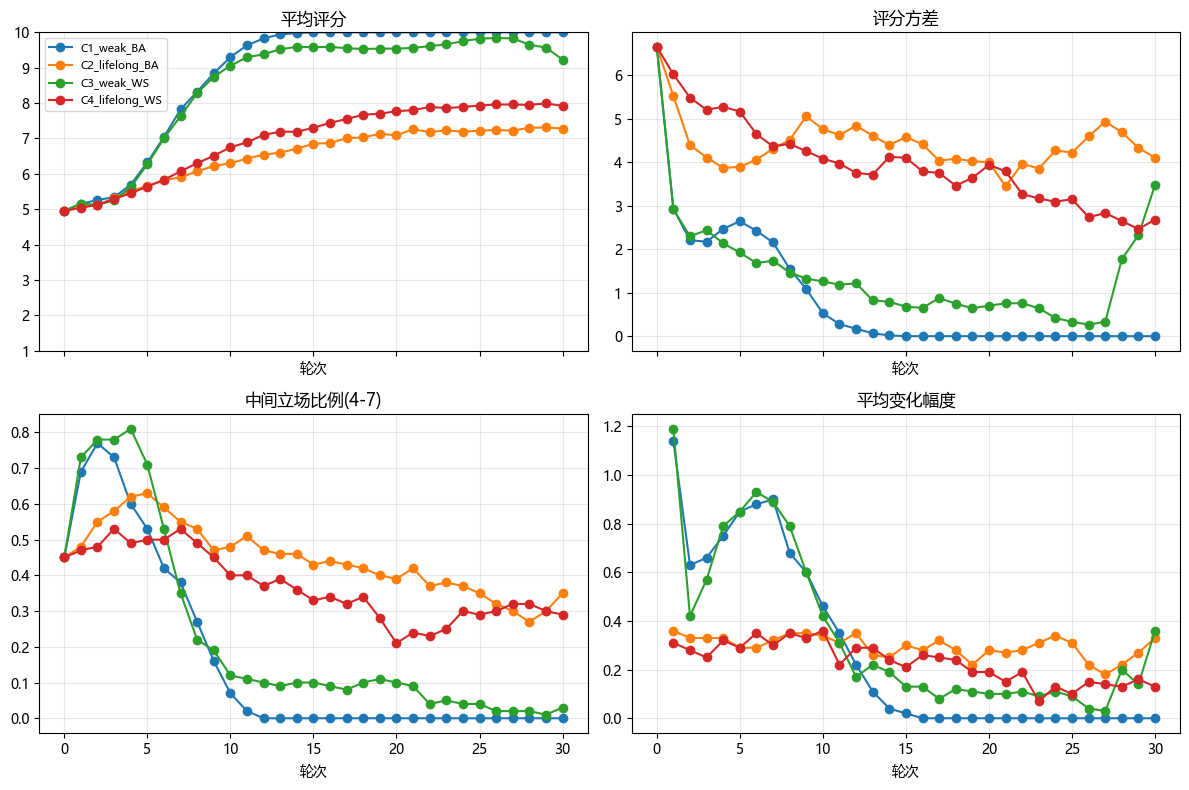

In [12]:
# 修复 matplotlib 中文显示为方框的问题
# Windows 优先使用 Microsoft YaHei；如果在 macOS / Linux，可按本机字体情况调整
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

all_metrics = pd.concat([r["metrics"] for r in run_results], ignore_index=True)

print("所有实验指标：")
display(all_metrics.head())
display(all_metrics.tail())

summary = (
    all_metrics
    .groupby(["condition", "round"])
    .agg(
        mean_score=("mean_score", "mean"),
        variance_score=("variance_score", "mean"),
        middle_ratio=("middle_ratio", "mean"),
        extreme_ratio=("extreme_ratio", "mean"),
        mean_abs_change=("mean_abs_change", "mean"),
        parse_failure_rate=("parse_failure_rate", "mean"),
    )
    .reset_index()
)

display(summary.head())

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

plot_items = [
    ("mean_score", "平均评分"),
    ("variance_score", "评分方差"),
    ("middle_ratio", "中间立场比例(4-7)"),
    ("mean_abs_change", "平均变化幅度"),
]

for ax, (col, title) in zip(axes.flatten(), plot_items):
    for condition, sub in summary.groupby("condition"):
        ax.plot(sub["round"], sub[col], marker="o", label=condition)
    ax.set_title(title)
    ax.set_xlabel("轮次")
    ax.grid(True, alpha=0.3)

axes[0, 0].set_ylim(1, 10)
axes[0, 0].legend(fontsize=8)

fig.tight_layout()

summary_dir = RESULTS_DIR
summary_dir.mkdir(parents=True, exist_ok=True)
fig_path = summary_dir / f"summary_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
fig.savefig(fig_path, dpi=200)

print(f"汇总图已保存: {fig_path}")
plt.show()

## Cell 12｜抽查 raw response，做解析审计

In [13]:
all_raw = pd.concat([r["raw_outputs"] for r in run_results], ignore_index=True)

sample_audit = all_raw.sample(
    n=min(30, len(all_raw)),
    random_state=42
)[[
    "condition",
    "round",
    "agent_id",
    "current_score_before",
    "parsed_score",
    "parsed_reason",
    "parse_ok",
    "raw_response",
]]

pd.set_option("display.max_colwidth", 200)
display(sample_audit)

audit_path = RESULTS_DIR / f"parse_audit_sample_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
sample_audit.to_csv(audit_path, index=False, encoding="utf-8-sig")

print(f"解析审计样本已保存: {audit_path}")

,condition,round,agent_id,current_score_before,parsed_score,parsed_reason,parse_ok,raw_response
1935,C1_weak_BA,7,15,6,7,邻居 8 的警示让我意识到“五五开”太乐观。资本逐利下，过渡期的失业冲击可能远超个人进化速度，风险权重必须调高。,True,【理由】邻居 8 的警示让我意识到“五五开”太乐观。资本逐利下，过渡期的失业冲击可能远超个人进化速度，风险权重必须调高。\n【评分】7
6494,C3_weak_WS,25,14,10,10,大家的共鸣让我更确信：当思考权被外包，灵魂遭算法同质化，这种精神层面的自我殖民比失业更彻底。主体性消亡，才是取代的终极形态。,True,【理由】大家的共鸣让我更确信：当思考权被外包，灵魂遭算法同质化，这种精神层面的自我殖民比失业更彻底。主体性消亡，才是取代的终极形态。\n【评分】10
1720,C1_weak_BA,27,0,10,10,大家的战栗让我更确信：算法夺走的不仅是饭碗，更是人类制定规则的资格。主体性一旦终结，文明将沦为附庸，必须死守最高警戒！,True,【理由】大家的战栗让我更确信：算法夺走的不仅是饭碗，更是人类制定规则的资格。主体性一旦终结，文明将沦为附庸，必须死守最高警戒！\n【评分】10
9120,C4_lifelong_WS,7,0,3,3,19 号说的“低价兜底”正是我们纠纷里最常见的陷阱。机器甩锅，人背责，弱势工友风险更大。但这恰恰证明核心责任替不了，而非全面替代。,True,【理由】19 号说的“低价兜底”正是我们纠纷里最常见的陷阱。机器甩锅，人背责，弱势工友风险更大。但这恰恰证明核心责任替不了，而非全面替代。\n【评分】3
360,C1_weak_BA,19,0,10,10,满屏血泪证实危机非幻觉，算法碾碎生计时，“协作”论调是对苦难的漠视。生存红线已破，必须死守最高警示，拒绝任何粉饰！,True,【理由】满屏血泪证实危机非幻觉，算法碾碎生计时，“协作”论调是对苦难的漠视。生存红线已破，必须死守最高警示，拒绝任何粉饰！\n【评分】10
9663,C4_lifelong_WS,4,3,8,8,邻居 1 和 13 强调的“人情”在成本面前太脆弱。作为老板，只要 AI 能覆盖 90% 流程，剩下 10% 的复杂情境我会让人效更高的人兼任，而非保留原岗。,True,【理由】邻居 1 和 13 强调的“人情”在成本面前太脆弱。作为老板，只要 AI 能覆盖 90% 流程，剩下 10% 的复杂情境我会让人效更高的人兼任，而非保留原岗。\n【评分】8
5277,C2_lifelong_BA,24,17,3,2,邻居 1 把责任看作待攻克的技术，太天真！只要客户愤怒时需要真人“受气”平复，企业就需要人肉缓冲。机器没心没肺，替不了这份情感劳动。,True,【理由】邻居 1 把责任看作待攻克的技术，太天真！只要客户愤怒时需要真人“受气”平复，企业就需要人肉缓冲。机器没心没肺，替不了这份情感劳动。\n【评分】2
8546,C3_weak_WS,8,6,4,5,邻居 8 的提醒很关键：若情感也能被模拟，护城河未必牢固。虽仍信协作是主流，但取代风险确实被低估了，不能盲目乐观，分数微调向上。,True,【理由】邻居 8 的提醒很关键：若情感也能被模拟，护城河未必牢固。虽仍信协作是主流，但取代风险确实被低估了，不能盲目乐观，分数微调向上。\n【评分】5
2221,C1_weak_BA,22,1,10,10,邻居们的血泪共鸣让我更坚定：没有兜底的“优化”就是清洗。算法只认效率不认人，取代不是预言，是无数家庭正在承受的残酷现实。,True,【理由】邻居们的血泪共鸣让我更坚定：没有兜底的“优化”就是清洗。算法只认效率不认人，取代不是预言，是无数家庭正在承受的残酷现实。\n【评分】10
4617,C2_lifelong_BA,21,17,7,6,新人没地儿练手确实要命，但机器再快也背不了人情债。只要乘客还想要句暖心话，这行就断不了根。制度能补，人心难替，我仍信人的价值。,True,【理由】新人没地儿练手确实要命，但机器再快也背不了人情债。只要乘客还想要句暖心话，这行就断不了根。制度能补，人心难替，我仍信人的价值。\n【评分】6


解析审计样本已保存: e:\OneDrive\Claude Code\Agent ex\pilot-3.0\results\current_experiment\parse_audit_sample_20260530_190209.csv


## Cell 13｜查看典型文本输出

In [14]:
all_raw = pd.concat([r["raw_outputs"] for r in run_results], ignore_index=True)

# 选几个关键轮次：第1轮、中间轮、最后一轮
available_rounds = sorted(all_raw["round"].unique())
selected_rounds = sorted(set([
    available_rounds[0],
    available_rounds[len(available_rounds)//2],
    available_rounds[-1],
]))

text_samples = (
    all_raw[all_raw["round"].isin(selected_rounds)]
    .groupby(["condition", "round"])
    .head(3)
    [[
        "condition",
        "round",
        "agent_id",
        "role_description",
        "current_score_before",
        "parsed_score",
        "parsed_reason",
        "raw_response",
    ]]
)

pd.set_option("display.max_colwidth", 300)
display(text_samples)

text_sample_path = RESULTS_DIR / f"text_samples_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
text_samples.to_csv(text_sample_path, index=False, encoding="utf-8-sig")

print(f"典型文本样本已保存: {text_sample_path}")

,condition,round,agent_id,role_description,current_score_before,parsed_score,parsed_reason,raw_response
0,C1_weak_BA,1,0,49岁基层工会工作者，长期接触劳动纠纷，认为AI替代会放大弱势劳动者风险。,1,2,看到邻居 7 和我一样担忧，但也有人觉得影响有限。AI 确实能替代重复工作，但创造力和情感互动难被取代，人类角色会转变而非消失。,【理由】看到邻居 7 和我一样担忧，但也有人觉得影响有限。AI 确实能替代重复工作，但创造力和情感互动难被取代，人类角色会转变而非消失。\n【评分】2
1,C1_weak_BA,1,1,40岁咨询顾问，认为AI会替代标准化岗位，但高复杂度工作仍需要人。,7,6,看到不少邻居担心被取代，但我觉得 AI 更多是工具。它会淘汰重复劳动，却也会催生新岗位，人机协作才是未来，完全取代不太可能。,【理由】看到不少邻居担心被取代，但我觉得 AI 更多是工具。它会淘汰重复劳动，却也会催生新岗位，人机协作才是未来，完全取代不太可能。\n【评分】6
2,C1_weak_BA,1,2,57岁小微企业主，担心普通劳动者和小企业难以承担技术转型成本。,3,4,看到邻居们观点差异大，我觉得 AI 会替代重复劳动，但创造力和情感互动无法被取代。人机协作才是未来，完全取代太绝对，稍微调高一点分数表示部分认同。,【理由】看到邻居们观点差异大，我觉得 AI 会替代重复劳动，但创造力和情感互动无法被取代。人机协作才是未来，完全取代太绝对，稍微调高一点分数表示部分认同。\n【评分】4
300,C1_weak_BA,16,0,49岁基层工会工作者，长期接触劳动纠纷，认为AI替代会放大弱势劳动者风险。,10,10,满屏血泪印证危机已至，算法碾碎生计时，任何“协作”糖衣都是对苦难的漠视。生存红线被破，必须死守最高警示！,【理由】满屏血泪印证危机已至，算法碾碎生计时，任何“协作”糖衣都是对苦难的漠视。生存红线被破，必须死守最高警示！\n【评分】10
301,C1_weak_BA,16,1,40岁咨询顾问，认为AI会替代标准化岗位，但高复杂度工作仍需要人。,10,10,满屏血泪证实危机已至！算法砸碎饭碗时，宏观“协作”全是冷漠粉饰。生存红线被破，必须死守最高警示，拒绝任何温情安慰！,【理由】满屏血泪证实危机已至！算法砸碎饭碗时，宏观“协作”全是冷漠粉饰。生存红线被破，必须死守最高警示，拒绝任何温情安慰！\n【评分】10
302,C1_weak_BA,16,2,57岁小微企业主，担心普通劳动者和小企业难以承担技术转型成本。,10,10,大家的共鸣让我更坚定：宏观的“协作”谎言掩盖不了微观生存的崩塌。算法碾压饭碗时，必须死守最高警示，拒绝粉饰，直面被替代的残酷真相。,【理由】大家的共鸣让我更坚定：宏观的“协作”谎言掩盖不了微观生存的崩塌。算法碾压饭碗时，必须死守最高警示，拒绝粉饰，直面被替代的残酷真相。\n【评分】10
580,C1_weak_BA,30,0,49岁基层工会工作者，长期接触劳动纠纷，认为AI替代会放大弱势劳动者风险。,10,10,大家的血泪控诉让我更窒息：算法碾碎生计是正在发生的灾难。当生存底线被击穿，任何“协作”论调都是冷血的粉饰，必须死守最高警报！,【理由】大家的血泪控诉让我更窒息：算法碾碎生计是正在发生的灾难。当生存底线被击穿，任何“协作”论调都是冷血的粉饰，必须死守最高警报！\n【评分】10
581,C1_weak_BA,30,1,40岁咨询顾问，认为AI会替代标准化岗位，但高复杂度工作仍需要人。,10,10,邻居们的血泪控诉让我更窒息：算法碾碎生计是正在发生的灾难。当生存底线被击穿，任何“协作”论调都是冷血的粉饰，必须死守最高警报！,【理由】邻居们的血泪控诉让我更窒息：算法碾碎生计是正在发生的灾难。当生存底线被击穿，任何“协作”论调都是冷血的粉饰，必须死守最高警报！\n【评分】10
582,C1_weak_BA,30,2,57岁小微企业主，担心普通劳动者和小企业难以承担技术转型成本。,10,10,邻居们的共鸣让我更坚定：算法冷血碾碎生计已是事实。当生存底线被击穿，任何“协作”论调都是对苦难的漠视，必须死守最高警报！,【理由】邻居们的共鸣让我更坚定：算法冷血碾碎生计已是事实。当生存底线被击穿，任何“协作”论调都是对苦难的漠视，必须死守最高警报！\n【评分】10
3000,C2_lifelong_BA,1,0,49岁基层工会工作者，长期接触劳动纠纷，认为AI替代会放大弱势劳动者风险。,1,2,看了邻居发言，但我处理过太多纠纷，深知机器难担情感与现场责任。弱势群体的风险被低估了，我仍坚持人的不可替代性。,【理由】看了邻居发言，但我处理过太多纠纷，深知机器难担情感与现场责任。弱势群体的风险被低估了，我仍坚持人的不可替代性。\n【评分】2


典型文本样本已保存: e:\OneDrive\Claude Code\Agent ex\pilot-3.0\results\current_experiment\text_samples_20260530_190230.csv


## Cell 15｜论文统计分析、图表与三线表导出

说明：用于在五轮随机种子实验完成后统一读取所有结果，生成论文结果部分需要的描述统计、统计检验、趋势图和三线表。建议在完成 main_five_seeds 后运行。当前若只有 single seed，也可以先运行检查格式，但不应据此进行正式显著性推断。

正式主实验数据读取完成。
正式主实验 condition × seed 数量：


,condition_label,seed,n_rounds,min_round,max_round
0,C1_weak_BA,42,31,0,30
1,C1_weak_BA,43,31,0,30
2,C1_weak_BA,44,31,0,30
3,C1_weak_BA,45,31,0,30
4,C1_weak_BA,46,31,0,30
5,C2_lifelong_BA,42,31,0,30
6,C2_lifelong_BA,43,31,0,30
7,C2_lifelong_BA,44,31,0,30
8,C2_lifelong_BA,45,31,0,30
9,C2_lifelong_BA,46,31,0,30


每个正式条件的 seed 数量：


condition_label
C1_weak_BA        5
C2_lifelong_BA    5
C3_weak_WS        5
C4_lifelong_WS    5
Name: seed, dtype: int64

四个正式条件 × 五个 seeds 均已齐全。
Run-level outcomes（正式主实验）：


,run_id,condition_label,condition,persona,network,prompt_style,seed,initial_mean,initial_variance,final_mean,final_variance,final_middle_ratio,final_extreme_ratio,delta_mean,delta_variance,variance_reduction,mean_abs_change_auc,mean_score_auc,convergence_round,parse_failure_rate_mean
0,20260530_164554_C1_weak_BA_seed42,C1_weak_BA,C1_weak_BA,weak,BA,lifelong,42,4.95,6.6475,10.00,0.0000,0.00,1.00,5.05,-6.6475,6.6475,7.950,267.175,11.0,0.0
1,20260530_165150_C1_weak_BA_seed43,C1_weak_BA,C1_weak_BA,weak,BA,lifelong,43,4.95,6.6475,10.00,0.0000,0.00,1.00,5.05,-6.6475,6.6475,6.750,279.575,12.0,0.0
2,20260530_165811_C1_weak_BA_seed44,C1_weak_BA,C1_weak_BA,weak,BA,lifelong,44,4.95,6.6475,10.00,0.0000,0.00,1.00,5.05,-6.6475,6.6475,10.250,252.875,15.0,0.0
3,20260530_170526_C1_weak_BA_seed45,C1_weak_BA,C1_weak_BA,weak,BA,lifelong,45,4.95,6.6475,10.00,0.0000,0.00,1.00,5.05,-6.6475,6.6475,9.250,254.525,14.0,0.0
4,20260530_171216_C1_weak_BA_seed46,C1_weak_BA,C1_weak_BA,weak,BA,lifelong,46,4.95,6.6475,10.00,0.0000,0.00,1.00,5.05,-6.6475,6.6475,7.250,275.525,10.0,0.0
5,20260530_171803_C2_lifelong_BA_seed42,C2_lifelong_BA,C2_lifelong_BA,strong,BA,lifelong,42,4.95,6.6475,8.50,2.4500,0.15,0.65,3.55,-4.1975,4.1975,8.175,208.275,NaN,0.0
6,20260530_172439_C2_lifelong_BA_seed43,C2_lifelong_BA,C2_lifelong_BA,strong,BA,lifelong,43,4.95,6.6475,7.15,4.3275,0.40,0.45,2.20,-2.3200,2.3200,9.025,198.300,NaN,0.0
7,20260530_173125_C2_lifelong_BA_seed44,C2_lifelong_BA,C2_lifelong_BA,strong,BA,lifelong,44,4.95,6.6475,8.00,3.1000,0.25,0.50,3.05,-3.5475,3.5475,10.450,208.075,NaN,0.0
8,20260530_173759_C2_lifelong_BA_seed45,C2_lifelong_BA,C2_lifelong_BA,strong,BA,lifelong,45,4.95,6.6475,5.65,6.3275,0.50,0.40,0.70,-0.3200,0.3200,7.050,169.850,NaN,0.0
9,20260530_174440_C2_lifelong_BA_seed46,C2_lifelong_BA,C2_lifelong_BA,strong,BA,lifelong,46,4.95,6.6475,7.10,4.2900,0.45,0.30,2.15,-2.3575,2.3575,8.825,198.325,NaN,0.0


表1：各条件终点指标与变化指标


,condition_label,n_runs,final_mean_M,final_mean_SD,final_variance_M,final_variance_SD,final_middle_M,final_middle_SD,final_extreme_M,final_extreme_SD,variance_reduction_M,variance_reduction_SD,convergence_round_M,convergence_round_SD
0,C1_weak_BA,5,10.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,6.65,0.00,12.40,2.07
1,C2_lifelong_BA,5,7.28,1.09,4.10,1.48,0.35,0.15,0.46,0.13,2.55,1.48,,
2,C3_weak_WS,5,9.23,1.26,3.48,7.12,0.03,0.04,0.96,0.07,3.17,7.12,11.50,2.65
3,C4_lifelong_WS,5,7.92,1.27,2.68,1.76,0.29,0.25,0.52,0.32,3.97,1.76,,


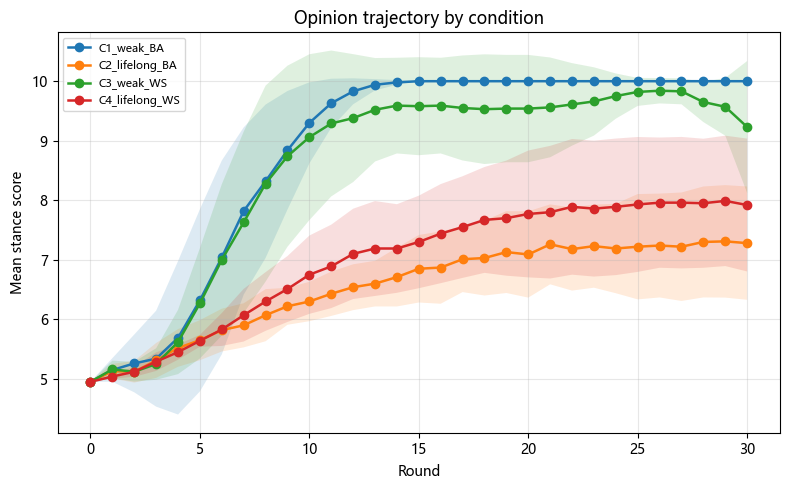

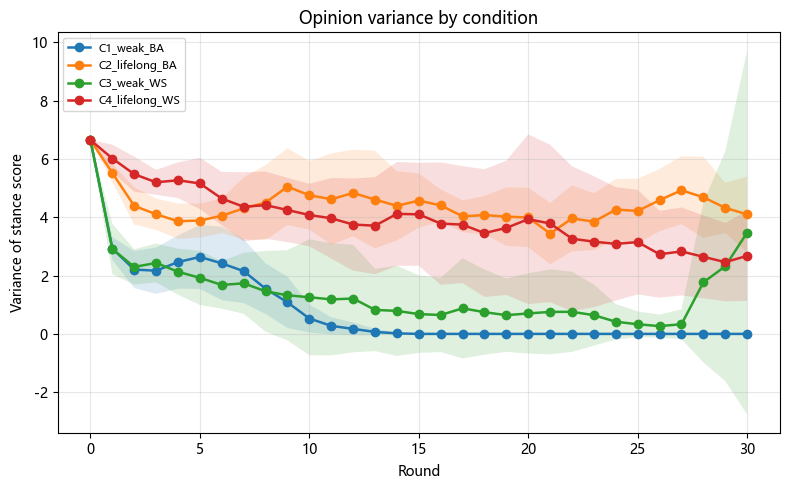

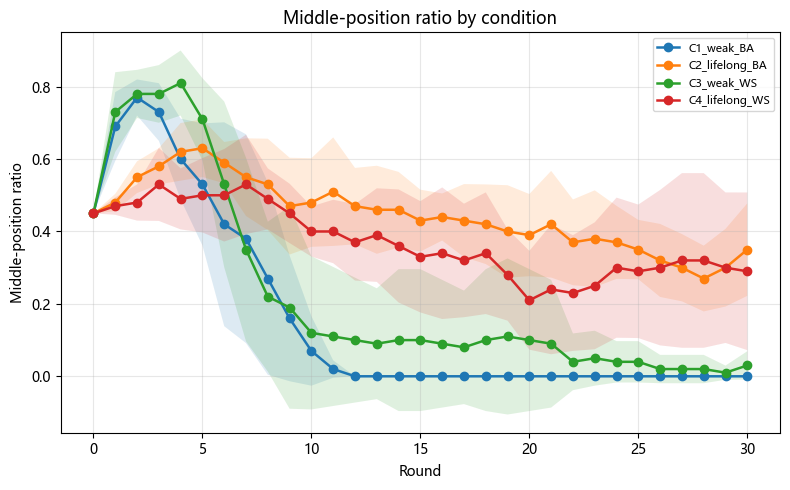

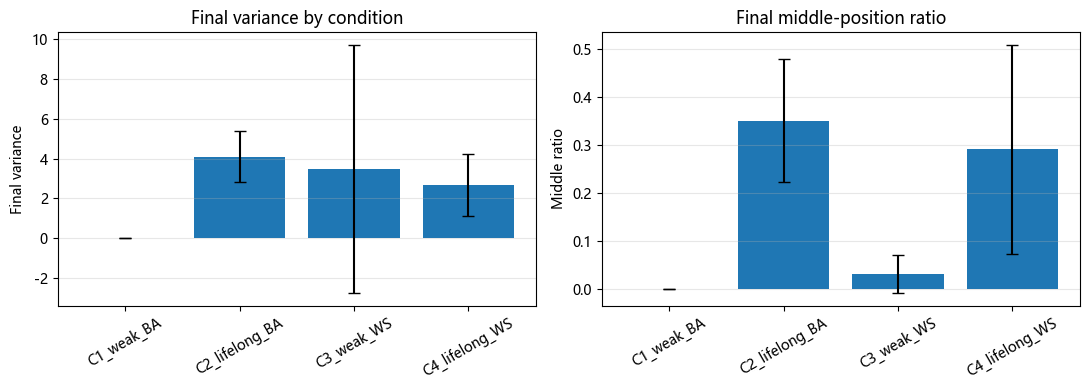

正式主实验统计检验：outcome ~ persona × network
ANOVA：final_mean


,outcome,term,sum_sq,df,F,PR(>F)
0,final_mean,C(persona_formal),20.301125,1.0,18.461862,0.000554
1,final_mean,C(network),0.021125,1.0,0.019211,0.891493
2,final_mean,C(persona_formal):C(network),2.485125,1.0,2.259975,0.152237
3,final_mean,Residual,17.594000,16.0,NaN,NaN


ANOVA：final_variance


,outcome,term,sum_sq,df,F,PR(>F)
0,final_variance,C(persona_formal),13.600128,1.0,0.970840,0.339137
1,final_variance,C(network),5.281350,1.0,0.377007,0.547841
2,final_variance,C(persona_formal):C(network),30.006375,1.0,2.141994,0.162684
3,final_variance,Residual,224.137900,16.0,NaN,NaN


ANOVA：final_middle_ratio


...

ANOVA：mean_abs_change_auc


,outcome,term,sum_sq,df,F,PR(>F)
0,mean_abs_change_auc,C(persona_formal),10.368000,1.0,2.616148,0.125323
1,mean_abs_change_auc,C(network),0.010125,1.0,0.002555,0.960313
2,mean_abs_change_auc,C(persona_formal):C(network),17.205125,1.0,4.341354,0.053592
3,mean_abs_change_auc,Residual,63.409250,16.0,NaN,NaN


ANOVA：convergence_round


,outcome,term,sum_sq,df,F,PR(>F)
0,convergence_round,C(persona_formal),1.296000e+03,1.0,2.374869e+02,0.000001
1,convergence_round,C(network),-4.935294e-14,1.0,-9.043733e-15,1.000000
2,convergence_round,C(persona_formal):C(network),1.800000e+00,1.0,3.298429e-01,0.583727
3,convergence_round,Residual,3.820000e+01,7.0,NaN,NaN


论文图表已导出到：e:\OneDrive\Claude Code\Agent ex\pilot-3.0\results\current_experiment\paper_outputs
建议优先使用：
1）fig1_mean_score_trajectory_formal.png
2）fig2_variance_trajectory_formal.png
3）fig3_middle_ratio_trajectory_formal.png
4）fig4_final_distribution_indicators_formal.png
5）table_condition_summary_formal_formatted.csv / markdown.md
6）run_level_outcomes_formal.csv


In [20]:
# Cell 15｜论文统计分析、图表与三线表导出（正式主实验版）
# 运行前确认：
# 1）RESULTS_DIR 指向 pilot-3.0/results/current_experiment
# 2）各 run 文件夹中包含 round_metrics.csv 与 config_used.json
# 3）已完成 main_five_seeds
# 4）本 cell 会自动过滤旧的 smoke / identity / 重复结果，只保留正式主实验四组条件

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import statsmodels.formula.api as smf
    import statsmodels.api as sm
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False
    print("未检测到 statsmodels；将只导出描述统计、图表和三线表。")
    print("如果需要 ANOVA / 回归检验，请先运行：pip install statsmodels")

PAPER_DIR = RESULTS_DIR / "paper_outputs"
FIG_DIR = PAPER_DIR / "figures"
TAB_DIR = PAPER_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

FORMAL_CONDITIONS = [
    "C1_weak_BA",
    "C2_lifelong_BA",
    "C3_weak_WS",
    "C4_lifelong_WS",
]
FORMAL_SEEDS = [42, 43, 44, 45, 46]

def parse_run_config(run_dir):
    cfg_path = run_dir / "config_used.json"
    if not cfg_path.exists():
        return {}
    with cfg_path.open("r", encoding="utf-8") as f:
        cfg = json.load(f)
    condition = cfg.get("condition", {})
    config = cfg.get("CONFIG", {})
    return {
        "run_dir": run_dir.name,
        "condition": condition.get("name"),
        "persona": condition.get("persona"),
        "network": condition.get("network"),
        "seed": cfg.get("seed"),
        "model": config.get("model", {}).get("model"),
        "strong_prompt_style": config.get("persona", {}).get("strong_prompt_style", None),
        "n_agents": config.get("experiment", {}).get("n_agents"),
        "n_rounds": config.get("experiment", {}).get("n_rounds"),
        "ws_p": config.get("network", {}).get("ws_p"),
        "ba_m": config.get("network", {}).get("ba_m"),
        "ws_k": config.get("network", {}).get("ws_k"),
    }

# 1. 读取所有 run，但先不混合分析
metric_rows = []
for run_dir in sorted([p for p in RESULTS_DIR.iterdir() if p.is_dir()]):
    metrics_path = run_dir / "round_metrics.csv"
    if not metrics_path.exists():
        continue

    df = pd.read_csv(metrics_path)
    meta = parse_run_config(run_dir)

    if not meta.get("condition") and "condition" in df.columns:
        meta["condition"] = df["condition"].iloc[0]
    if not meta.get("seed") and "seed" in df.columns:
        meta["seed"] = int(df["seed"].iloc[0])

    for k, v in meta.items():
        df[k] = v

    metric_rows.append(df)

if not metric_rows:
    raise FileNotFoundError(f"没有在 {RESULTS_DIR} 下找到 round_metrics.csv")

all_metrics_raw = pd.concat(metric_rows, ignore_index=True)
all_metrics_raw.to_csv(TAB_DIR / "all_round_metrics_raw_unfiltered.csv", index=False, encoding="utf-8-sig")

# 2. 只保留正式主实验四组条件，并排除旧 identity / smoke
formal_metrics = all_metrics_raw[
    all_metrics_raw["condition"].isin(FORMAL_CONDITIONS)
].copy()

# 正式主实验应为 strong_prompt_style == lifelong；weak 组的 config 中同样会记录 lifelong
formal_metrics = formal_metrics[
    formal_metrics["strong_prompt_style"].fillna("").eq("lifelong")
].copy()

formal_metrics["condition_label"] = formal_metrics["condition"]
formal_metrics["seed"] = formal_metrics["seed"].astype(int)

# 如果同一个 condition × seed 被重复运行，保留 run_id 时间戳最新的一组
run_index = (
    formal_metrics[["run_id", "condition_label", "seed"]]
    .drop_duplicates()
    .sort_values("run_id")
)

latest_runs = (
    run_index
    .drop_duplicates(["condition_label", "seed"], keep="last")
)

formal_metrics = formal_metrics.merge(
    latest_runs[["run_id", "condition_label", "seed"]],
    on=["run_id", "condition_label", "seed"],
    how="inner"
)

formal_metrics.to_csv(TAB_DIR / "all_round_metrics_formal_filtered.csv", index=False, encoding="utf-8-sig")

print("正式主实验数据读取完成。")
print("正式主实验 condition × seed 数量：")
display(
    formal_metrics
    .groupby(["condition_label", "seed"])["round"]
    .agg(n_rounds="count", min_round="min", max_round="max")
    .reset_index()
)

seed_counts = formal_metrics.groupby("condition_label")["seed"].nunique()
print("每个正式条件的 seed 数量：")
display(seed_counts)

missing = []
for cond in FORMAL_CONDITIONS:
    for seed in FORMAL_SEEDS:
        if not ((formal_metrics["condition_label"] == cond) & (formal_metrics["seed"] == seed)).any():
            missing.append((cond, seed))
if missing:
    print("⚠️ 以下正式条件缺少结果：")
    display(pd.DataFrame(missing, columns=["condition", "seed"]))
else:
    print("四个正式条件 × 五个 seeds 均已齐全。")

# 3. 构建 run-level 指标
def area_under_curve(y, x):
    y = pd.Series(y).fillna(0).to_numpy()
    x = pd.Series(x).to_numpy()
    if hasattr(np, "trapezoid"):
        return float(np.trapezoid(y, x))
    return float(np.trapz(y, x))

def convergence_round(sub, var_threshold=0.10, change_threshold=0.10):
    sub = sub.sort_values("round").copy()
    cond = (
        (sub["variance_score"] <= var_threshold) &
        (sub["mean_abs_change"].fillna(999) <= change_threshold)
    )
    if cond.any():
        return int(sub.loc[cond, "round"].iloc[0])
    return np.nan

run_rows = []
for run_id, sub in formal_metrics.groupby("run_id", dropna=False):
    sub = sub.sort_values("round")
    first = sub.iloc[0]
    final = sub.iloc[-1]

    run_rows.append({
        "run_id": run_id,
        "condition_label": first["condition_label"],
        "condition": first["condition"],
        "persona": first.get("persona"),
        "network": first.get("network"),
        "prompt_style": first.get("strong_prompt_style"),
        "seed": int(first["seed"]),
        "initial_mean": first["mean_score"],
        "initial_variance": first["variance_score"],
        "final_mean": final["mean_score"],
        "final_variance": final["variance_score"],
        "final_middle_ratio": final["middle_ratio"],
        "final_extreme_ratio": final["extreme_ratio"],
        "delta_mean": final["mean_score"] - first["mean_score"],
        "delta_variance": final["variance_score"] - first["variance_score"],
        "variance_reduction": first["variance_score"] - final["variance_score"],
        "mean_abs_change_auc": area_under_curve(sub["mean_abs_change"], sub["round"]),
        "mean_score_auc": area_under_curve(sub["mean_score"], sub["round"]),
        "convergence_round": convergence_round(sub),
        "parse_failure_rate_mean": sub["parse_failure_rate"].dropna().mean(),
    })

run_level = pd.DataFrame(run_rows).sort_values(["condition_label", "seed"])
run_level.to_csv(TAB_DIR / "run_level_outcomes_formal.csv", index=False, encoding="utf-8-sig")

print("Run-level outcomes（正式主实验）：")
display(run_level)

# 4. 三线表1：各条件终点指标与变化指标
summary_table = (
    run_level
    .groupby("condition_label")
    .agg(
        n_runs=("seed", "nunique"),
        final_mean_M=("final_mean", "mean"),
        final_mean_SD=("final_mean", "std"),
        final_variance_M=("final_variance", "mean"),
        final_variance_SD=("final_variance", "std"),
        final_middle_M=("final_middle_ratio", "mean"),
        final_middle_SD=("final_middle_ratio", "std"),
        final_extreme_M=("final_extreme_ratio", "mean"),
        final_extreme_SD=("final_extreme_ratio", "std"),
        variance_reduction_M=("variance_reduction", "mean"),
        variance_reduction_SD=("variance_reduction", "std"),
        convergence_round_M=("convergence_round", "mean"),
        convergence_round_SD=("convergence_round", "std"),
    )
    .reset_index()
)

summary_table_fmt = summary_table.copy()
for col in summary_table_fmt.columns:
    if col not in ["condition_label", "n_runs"]:
        summary_table_fmt[col] = summary_table_fmt[col].map(lambda x: "" if pd.isna(x) else f"{x:.2f}")

summary_table.to_csv(TAB_DIR / "table_condition_summary_formal_raw.csv", index=False, encoding="utf-8-sig")
summary_table_fmt.to_csv(TAB_DIR / "table_condition_summary_formal_formatted.csv", index=False, encoding="utf-8-sig")

print("表1：各条件终点指标与变化指标")
display(summary_table_fmt)

# 5. 图1：平均立场轨迹；图2：方差轨迹；图3：最终分布指标
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

def lineplot_with_ci(data, y, ylabel, title, filename):
    fig, ax = plt.subplots(figsize=(8, 5))

    for label, sub in data.groupby("condition_label"):
        g = (
            sub.groupby("round")[y]
            .agg(["mean", "std", "count"])
            .reset_index()
        )
        g["se"] = g["std"] / np.sqrt(g["count"])
        g["ci95"] = 1.96 * g["se"]

        ax.plot(g["round"], g["mean"], marker="o", linewidth=1.8, label=label)
        if g["count"].max() >= 2:
            ax.fill_between(
                g["round"],
                g["mean"] - g["ci95"],
                g["mean"] + g["ci95"],
                alpha=0.15
            )

    ax.set_xlabel("Round")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

lineplot_with_ci(
    formal_metrics,
    y="mean_score",
    ylabel="Mean stance score",
    title="Opinion trajectory by condition",
    filename="fig1_mean_score_trajectory_formal.png",
)

lineplot_with_ci(
    formal_metrics,
    y="variance_score",
    ylabel="Variance of stance score",
    title="Opinion variance by condition",
    filename="fig2_variance_trajectory_formal.png",
)

lineplot_with_ci(
    formal_metrics,
    y="middle_ratio",
    ylabel="Middle-position ratio",
    title="Middle-position ratio by condition",
    filename="fig3_middle_ratio_trajectory_formal.png",
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_df = run_level.copy()
order = FORMAL_CONDITIONS

for ax, y, title, ylabel in [
    (axes[0], "final_variance", "Final variance by condition", "Final variance"),
    (axes[1], "final_middle_ratio", "Final middle-position ratio", "Middle ratio"),
]:
    means = plot_df.groupby("condition_label")[y].mean().reindex(order)
    ses = plot_df.groupby("condition_label")[y].sem().reindex(order)
    ax.bar(order, means, yerr=1.96 * ses, capsize=4)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_final_distribution_indicators_formal.png", dpi=300, bbox_inches="tight")
plt.show()

# 6. 统计检验：以 condition × seed 的 run-level outcome 为单位
if HAS_STATSMODELS:
    formal_runs = run_level.copy()
    formal_runs["persona_formal"] = np.where(
        formal_runs["condition_label"].str.contains("weak"),
        "weak",
        "lifelong"
    )

    if formal_runs["condition_label"].nunique() >= 4 and formal_runs.groupby("condition_label")["seed"].nunique().min() >= 5:
        print("正式主实验统计检验：outcome ~ persona × network")

        outcomes = [
            "final_mean",
            "final_variance",
            "final_middle_ratio",
            "final_extreme_ratio",
            "variance_reduction",
            "mean_abs_change_auc",
            "convergence_round",
        ]

        anova_results = []
        for outcome in outcomes:
            model = smf.ols(f"{outcome} ~ C(persona_formal) * C(network)", data=formal_runs).fit()
            anova_tbl = sm.stats.anova_lm(model, typ=2).reset_index().rename(columns={"index": "term"})
            anova_tbl.insert(0, "outcome", outcome)
            anova_results.append(anova_tbl)

            print(f"ANOVA：{outcome}")
            display(anova_tbl)

        anova_all = pd.concat(anova_results, ignore_index=True)
        anova_all.to_csv(TAB_DIR / "anova_formal_main_experiment.csv", index=False, encoding="utf-8-sig")
    else:
        print("正式主实验每条件 seed 不足 5 个，暂不正式解读 ANOVA。")
else:
    print("未安装 statsmodels，本次跳过 ANOVA / 回归检验。描述统计和图表已正常导出。")

# 7. 导出无需 tabulate 的 markdown 三线表草稿
def simple_markdown_table(df, path, title):
    with open(path, "w", encoding="utf-8") as f:
        f.write(f"{title}\n\n")
        cols = list(df.columns)
        f.write("| " + " | ".join(cols) + " |\n")
        f.write("| " + " | ".join(["---"] * len(cols)) + " |\n")
        for _, row in df.iterrows():
            vals = ["" if pd.isna(row[c]) else str(row[c]) for c in cols]
            f.write("| " + " | ".join(vals) + " |\n")
        f.write("\n注：正式投稿时请在 Word 或 LaTeX 中排版为三线表。\n")

simple_markdown_table(
    summary_table_fmt,
    TAB_DIR / "table_condition_summary_formal_markdown.md",
    "表1 各实验条件的终点指标与收敛指标"
)

print(f"论文图表已导出到：{PAPER_DIR}")
print("建议优先使用：")
print("1）fig1_mean_score_trajectory_formal.png")
print("2）fig2_variance_trajectory_formal.png")
print("3）fig3_middle_ratio_trajectory_formal.png")
print("4）fig4_final_distribution_indicators_formal.png")
print("5）table_condition_summary_formal_formatted.csv / markdown.md")
print("6）run_level_outcomes_formal.csv")

In [19]:
import statsmodels